<a href="https://colab.research.google.com/github/imak2363/violence-detection/blob/main/iolence_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lightweight Temporal Violence Detection Using YOLOv7-Tiny and Bi-GRU


## 1. Install Dependencies

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q opencv-python-headless
!pip install -q scikit-learn matplotlib seaborn
!pip install -q optuna
!pip install -q grad-cam
!pip install -q gdown
print('All dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 32.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
All dependencies installed.


## 2. Imports and Configuration

In [ ]:
import os
import cv2
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import threading
import time
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Hyper-parameters (defaults; Optuna may override) ─────────────────────────
CFG = {
    'img_size'       : 224,
    'seq_len'        : 8,
    'frame_stride'   : 2,          # sample every 2nd frame
    'batch_size'     : 16,
    'num_epochs'     : 30,
    'lr'             : 1e-3,
    'weight_decay'   : 1e-4,
    'gru_hidden'     : 256,
    'gru_layers'     : 2,
    'dropout'        : 0.5,
    'num_classes'    : 2,
    'patience'       : 7,          # early stopping patience
    'num_workers'    : 2,
}

Using device: cpu


## 3. Dataset Preparation (UCF-Crime)

In [ ]:
import zipfile
import os

zip_path = '/content/UCF_Crime.zip'   # ← change if your filename is different
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [ ]:
import os
import random

DATA_ROOT = '/content/ucf_crime'

# ── Helper: collect (path, label) pairs ──────────────────────────────────────
def collect_video_paths(root, max_per_class=140):
    """Returns a balanced list of (video_path, label) tuples for all classes,
    along with the number of classes and class-to-label mapping.
    """
    all_class_names = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
    class_to_label = {name: i for i, name in enumerate(all_class_names)}

    samples = []
    for cls_name, label in class_to_label.items():
        folder = os.path.join(root, cls_name)
        if not os.path.isdir(folder):
            print(f'[WARN] Missing folder: {folder}')
            continue
        videos = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.mp4', '.avi', '.mkv'))]
        random.shuffle(videos)
        videos = videos[:max_per_class]
        for v in videos:
            samples.append((os.path.join(folder, v), label))
    random.shuffle(samples)
    return samples, len(all_class_names), class_to_label

all_samples, num_actual_classes, class_label_mapping = collect_video_paths(DATA_ROOT, max_per_class=140)

# Update CFG with the actual number of classes
CFG['num_classes'] = num_actual_classes

# Create a list of class names ordered by their label
CLASS_NAMES = [name for name, label in sorted(class_label_mapping.items(), key=lambda item: item[1])]


split_idx   = int(0.8 * len(all_samples))
train_samples = all_samples[:split_idx]
test_samples  = all_samples[split_idx:]
print(f'Detected classes: {class_label_mapping}')
print(f'Total classes: {CFG["num_classes"]}')
print(f'Total samples: {len(all_samples)} | Train: {len(train_samples)} | Test: {len(test_samples)}')

Detected classes: {'Normal': 0, 'Violence': 1}
Total classes: 2
Total samples: 177 | Train: 141 | Test: 36


In [ ]:
import shutil
import os

folder_path = '/content/ucf_crime/.ipynb_checkpoints'

if os.path.exists(folder_path):
    shutil.rmtree(folder_path)
    print(f'Folder \'{folder_path}\' deleted successfully.')
else:
    print(f'Folder \'{folder_path}\' does not exist.')

Folder '/content/ucf_crime/.ipynb_checkpoints' does not exist.


## 4. Preprocessing Pipeline

In [ ]:
def apply_gaussian_blur(frame):
    """Noise reduction with Gaussian blur."""
    return cv2.GaussianBlur(frame, (3, 3), 0)

def apply_clahe(frame):
    """Contrast Limited Adaptive Histogram Equalization (CLAHE) for
    improving local contrast, especially in low-light frames."""
    lab   = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l     = clahe.apply(l)
    lab   = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def preprocess_frame(frame, img_size=224):
    """Full preprocessing pipeline applied to every frame:
    resize → Gaussian blur → CLAHE → normalize.
    """
    frame = cv2.resize(frame, (img_size, img_size))
    frame = apply_gaussian_blur(frame)
    frame = apply_clahe(frame)
    frame = frame.astype(np.float32) / 255.0
    # ImageNet-style normalisation
    mean  = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std   = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    frame = (frame - mean) / std
    return frame  # H × W × C

# ── Data-augmentation transforms (training only) ─────────────────────────────
def augment_frame(frame, is_train=True):
    """Random augmentations to improve generalisation:
    horizontal flip, brightness/contrast jitter, simulated low-light,
    motion blur, compression artefacts, random noise.
    """
    if not is_train:
        return frame

    # Random horizontal flip
    if random.random() > 0.5:
        frame = cv2.flip(frame, 1)

    # Brightness / contrast jitter
    if random.random() > 0.5:
        alpha = random.uniform(0.8, 1.2)   # contrast
        beta  = random.uniform(-20, 20)    # brightness
        frame = np.clip(frame * alpha + beta, 0, 255).astype(np.uint8)

    # Simulated low-light
    if random.random() > 0.7:
        gamma  = random.uniform(0.4, 0.8)
        table  = np.array([(i / 255.0) ** gamma * 255
                           for i in range(256)], dtype=np.uint8)
        frame  = cv2.LUT(frame, table)

    # Motion blur
    if random.random() > 0.7:
        k      = random.choice([3, 5])
        kernel = np.zeros((k, k), dtype=np.float32)
        kernel[k // 2, :] = 1.0 / k
        frame  = cv2.filter2D(frame, -1, kernel)

    # JPEG compression artefacts
    if random.random() > 0.7:
        quality = random.randint(50, 90)
        _, enc  = cv2.imencode('.jpg', frame,
                               [cv2.IMWRITE_JPEG_QUALITY, quality])
        frame   = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    # Random Gaussian noise
    if random.random() > 0.7:
        noise = np.random.normal(0, 5, frame.shape).astype(np.float32)
        frame = np.clip(frame.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return frame

## 5. Dataset Class

In [ ]:
class ViolenceDataset(Dataset):
    """Loads fixed-length frame sequences from video files.

    Each sample is a tensor of shape (seq_len, C, H, W).
    Frames are sampled with stride `frame_stride` (every 2nd frame per the paper).
    """

    def __init__(self, samples, cfg, is_train=True):
        self.samples      = samples
        self.cfg          = cfg
        self.is_train     = is_train
        self.seq_len      = cfg['seq_len']
        self.frame_stride = cfg['frame_stride']
        self.img_size     = cfg['img_size']

    def __len__(self):
        return len(self.samples)

    def _load_frames(self, video_path):
        cap    = cv2.VideoCapture(video_path)
        frames = []
        while len(frames) < self.seq_len * self.frame_stride:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
        cap.release()

        # Select every frame_stride-th frame
        selected = frames[::self.frame_stride][:self.seq_len]

        # Pad with the last frame if the video is shorter than required
        while len(selected) < self.seq_len:
            selected.append(selected[-1] if selected else
                            np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        return selected

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        raw_frames = self._load_frames(video_path)

        processed = []
        for frame in raw_frames:
            frame = augment_frame(frame, self.is_train)
            frame = preprocess_frame(frame, self.img_size)
            # H × W × C  →  C × H × W
            frame = torch.tensor(frame, dtype=torch.float32).permute(2, 0, 1)
            processed.append(frame)

        # (seq_len, C, H, W)
        sequence = torch.stack(processed, dim=0)
        return sequence, torch.tensor(label, dtype=torch.long)


# ── DataLoaders ───────────────────────────────────────────────────────────────
train_dataset = ViolenceDataset(train_samples, CFG, is_train=True)
test_dataset  = ViolenceDataset(test_samples,  CFG, is_train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG['batch_size'],
    shuffle     = True,
    num_workers = CFG['num_workers'],
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = CFG['batch_size'],
    shuffle     = False,
    num_workers = CFG['num_workers'],
    pin_memory  = True
)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 9 | Test batches: 3


## 6. Model Architecture

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  YOLOv7-Tiny-inspired Spatial Feature Extractor
# ─────────────────────────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Conv → BatchNorm → SiLU (Sigmoid-weighted Linear Unit)."""
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p, bias=False),
            nn.BatchNorm2d(out_c),
            nn.SiLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)


class YOLOv7TinyExtractor(nn.Module):
    """Simplified YOLOv7-Tiny backbone — 5 progressive convolutional blocks
    that reduce spatial resolution while increasing channel depth.
    Outputs a fixed-size feature vector per frame.
    """
    def __init__(self, img_size=224, out_dim=512):
        super().__init__()
        # Block 1  224 → 112
        self.block1 = nn.Sequential(
            ConvBlock(3,  32, k=3, s=2, p=1),
            ConvBlock(32, 64, k=3, s=1, p=1),
        )
        # Block 2  112 → 56
        self.block2 = nn.Sequential(
            ConvBlock(64, 128, k=3, s=2, p=1),
            ConvBlock(128, 128, k=1, s=1, p=0),
            ConvBlock(128, 128, k=3, s=1, p=1),
        )
        # Block 3  56 → 28
        self.block3 = nn.Sequential(
            ConvBlock(128, 256, k=3, s=2, p=1),
            ConvBlock(256, 128, k=1, s=1, p=0),
            ConvBlock(128, 256, k=3, s=1, p=1),
        )
        # Block 4  28 → 14
        self.block4 = nn.Sequential(
            ConvBlock(256, 512, k=3, s=2, p=1),
            ConvBlock(512, 256, k=1, s=1, p=0),
            ConvBlock(256, 512, k=3, s=1, p=1),
        )
        # Block 5  14 → 7
        self.block5 = nn.Sequential(
            ConvBlock(512, 1024, k=3, s=2, p=1),
            ConvBlock(1024, 512, k=1, s=1, p=0),
            ConvBlock(512, 1024, k=3, s=1, p=1),
        )
        # Global average pool → flat vector
        self.pool    = nn.AdaptiveAvgPool2d(1)
        self.project = nn.Linear(1024, out_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):           # x: (B, C, H, W)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.pool(x).flatten(1) # (B, 1024)
        x = self.dropout(x)
        x = self.project(x)         # (B, out_dim)
        return x


# ─────────────────────────────────────────────────────────────────────────────
#  Frame-level Attention
# ─────────────────────────────────────────────────────────────────────────────
class FrameAttention(nn.Module):
    """Scalar attention weight for each frame in the sequence."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):           # x: (B, T, H)
        scores  = self.attn(x)      # (B, T, 1)
        weights = torch.softmax(scores, dim=1)  # (B, T, 1)
        context = (x * weights).sum(dim=1)      # (B, H)
        return context, weights


# ─────────────────────────────────────────────────────────────────────────────
#  Full Model: YOLOv7-Tiny + Bi-GRU + Frame Attention
# ─────────────────────────────────────────────────────────────────────────────
class ViolenceDetector(nn.Module):
    """End-to-end violence detection model.

    Input : (B, T, C, H, W)  — batch of frame sequences
    Output: (B, num_classes) — class logits
    """
    def __init__(self, cfg):
        super().__init__()
        feat_dim    = 512
        hidden_dim  = cfg['gru_hidden']   # 256 per side → 512 bidirectional

        self.extractor = YOLOv7TinyExtractor(cfg['img_size'], out_dim=feat_dim)

        self.bigru = nn.GRU(
            input_size   = feat_dim,
            hidden_size  = hidden_dim,
            num_layers   = cfg['gru_layers'],
            batch_first  = True,
            bidirectional= True,
            dropout      = cfg['dropout'] if cfg['gru_layers'] > 1 else 0.0,
        )

        self.attention = FrameAttention(hidden_dim * 2)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg['dropout']),
            nn.Linear(128, cfg['num_classes']),
        )

    def forward(self, x):           # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape

        # Extract spatial features frame-by-frame
        x = x.view(B * T, C, H, W)
        features = self.extractor(x)        # (B*T, feat_dim)
        features = features.view(B, T, -1)  # (B, T, feat_dim)

        # Temporal modeling with Bi-GRU
        gru_out, _ = self.bigru(features)   # (B, T, hidden*2)

        # Frame-level attention
        context, _ = self.attention(gru_out) # (B, hidden*2)

        # Classification
        logits = self.classifier(context)   # (B, num_classes)
        return logits


model = ViolenceDetector(CFG).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 16,330,275


## 7. Loss, Optimizer, and Scheduler

In [ ]:
# ── Class-weighted cross-entropy to handle class imbalance ───────────────────
from sklearn.utils.class_weight import compute_class_weight

train_labels = [s[1] for s in train_samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f'Class weights: {class_weights}')

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay']
)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0     = 10,
    T_mult  = 2,
    eta_min = 1e-6
)

# Mixed-precision scaler
scaler = GradScaler()
print('Optimizer, scheduler, and mixed-precision scaler ready.')

Class weights: tensor([0.7194, 1.6395])
Optimizer, scheduler, and mixed-precision scaler ready.


## 8. Adaptive Frame Control (AFC)

In [ ]:
class AdaptiveFrameController:
    """Simulates the AFC mechanism described in the paper (Lee & Hwang, 2022).

    Maintains a bounded queue of frames.  When the detection service is slower
    than the frame arrival rate (Ta < Ds), stale frames are dropped and only
    the most recent frame is kept, preventing latency accumulation.
    """

    def __init__(self, target_fps=30, queue_size=32):
        self.target_fps  = target_fps
        self.queue       = deque(maxlen=queue_size)
        self.lock        = threading.Lock()
        self.frame_count = 0
        self.dropped     = 0
        self.ta          = 1.0 / target_fps  # interarrival time

    def enqueue(self, frame):
        """Add a new frame (called by the prefetcher thread)."""
        with self.lock:
            self.queue.append(frame)
            self.frame_count += 1

    def get_latest(self, ds):
        """Return the most recent frame, dropping stale ones if Ta < Ds.

        ds: detection service time in seconds
        """
        with self.lock:
            if not self.queue:
                return None
            if self.ta < ds and len(self.queue) > 1:
                dropped = len(self.queue) - 1
                self.dropped += dropped
                # Keep only the latest frame
                latest = self.queue[-1]
                self.queue.clear()
                self.queue.append(latest)
            return self.queue.popleft() if self.queue else None

    def stats(self):
        return {'total_frames': self.frame_count, 'dropped_frames': self.dropped}


# Quick functional test
afc = AdaptiveFrameController(target_fps=30)
for i in range(10):
    afc.enqueue(np.zeros((224, 224, 3), dtype=np.uint8))
frame = afc.get_latest(ds=0.05)  # 50 ms detection → slower than 33 ms arrival
print(f'AFC test — queue emptied to latest frame. Stats: {afc.stats()}')

AFC test — queue emptied to latest frame. Stats: {'total_frames': 10, 'dropped_frames': 9}


## 9. Hyperparameter Optimization with Optuna

In [ ]:
import optuna
from optuna.samplers import TPESampler

def quick_eval(model, loader, device):
    """One pass over loader, returns accuracy."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for seqs, labels in loader:
            seqs, labels = seqs.to(device), labels.to(device)
            with autocast():
                out = model(seqs)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return correct / total


def optuna_objective(trial):
    """Optuna objective — searches over key hyperparameters."""
    trial_cfg = {
        **CFG,
        'lr'         : trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'gru_hidden' : trial.suggest_categorical('gru_hidden', [128, 256, 512]),
        'dropout'    : trial.suggest_float('dropout', 0.3, 0.6),
        'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
    }

    trial_model = ViolenceDetector(trial_cfg).to(DEVICE)
    trial_opt   = optim.AdamW(trial_model.parameters(),
                              lr=trial_cfg['lr'],
                              weight_decay=trial_cfg['weight_decay'])
    trial_scaler = GradScaler()

    # Train for 3 quick epochs
    for epoch in range(3):
        trial_model.train()
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
            trial_opt.zero_grad()
            with autocast():
                loss = criterion(trial_model(seqs), labels)
            trial_scaler.scale(loss).backward()
            trial_scaler.step(trial_opt)
            trial_scaler.update()

    return quick_eval(trial_model, test_loader, DEVICE)


print('Running Optuna hyperparameter search (5 trials) …')
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study.optimize(optuna_objective, n_trials=5, show_progress_bar=True)

best_params = study.best_params
print(f'Best params: {best_params}')
print(f'Best val accuracy: {study.best_value:.4f}')

# Update CFG with best found hyperparameters
CFG.update(best_params)

[I 2026-03-31 17:19:32,138] A new study created in memory with name: no-name-ba5e13ed-0bc3-4b95-9a00-7459d155b88b


Running Optuna hyperparameter search (5 trials) …


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-03-31 17:42:03,167] Trial 0 finished with value: 0.4444444444444444 and parameters: {'lr': 0.0005611516415334506, 'gru_hidden': 128, 'dropout': 0.34680559213273093, 'weight_decay': 2.0511104188433963e-05}. Best is trial 0 with value: 0.4444444444444444.
[I 2026-03-31 18:04:49,053] Trial 1 finished with value: 0.2777777777777778 and parameters: {'lr': 0.00013066739238053285, 'gru_hidden': 128, 'dropout': 0.3061753482887407, 'weight_decay': 0.0008706020878304854}. Best is trial 0 with value: 0.4444444444444444.
[I 2026-03-31 18:27:12,167] Trial 2 finished with value: 0.25 and parameters: {'lr': 0.004622589001020831, 'gru_hidden': 128, 'dropout': 0.3912726728878613, 'weight_decay': 0.00011207606211860574}. Best is trial 0 with value: 0.4444444444444444.
[I 2026-03-31 18:49:26,164] Trial 3 finished with value: 0.3888888888888889 and parameters: {'lr': 0.0007309539835912913, 'gru_hidden': 256, 'dropout': 0.3876433945605654, 'weight_decay': 5.4041038546473305e-05}. Best is trial 0 wi

## 10. Training Loop (Mixed-Precision + Early Stopping)

In [ ]:
# Re-initialise model with best hyperparameters
model     = ViolenceDetector(CFG).to(DEVICE)
optimizer = optim.AdamW(model.parameters(),
                        lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6)
scaler    = GradScaler()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
patience_ctr  = 0
CKPT_PATH     = '/content/best_model.pth'

print('Starting training …')
for epoch in range(1, CFG['num_epochs'] + 1):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0

    for seqs, labels in train_loader:
        seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with autocast():
            logits = model(seqs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        tr_loss    += loss.item() * labels.size(0)
        tr_correct += (logits.argmax(1) == labels).sum().item()
        tr_total   += labels.size(0)

    scheduler.step()

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for seqs, labels in test_loader:
            seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                logits = model(seqs)
                loss   = criterion(logits, labels)
            val_loss    += loss.item() * labels.size(0)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    tr_acc  = tr_correct  / tr_total
    val_acc = val_correct / val_total
    tr_l    = tr_loss  / tr_total
    val_l   = val_loss / val_total

    history['train_loss'].append(tr_l)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_l)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch:02d}/{CFG["num_epochs"]}]  '
          f'Train Loss: {tr_l:.4f}  Train Acc: {tr_acc:.4f}  '
          f'Val Loss: {val_l:.4f}  Val Acc: {val_acc:.4f}')

    # ── Early stopping + checkpoint ──────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  ✓ Checkpoint saved (val_acc={val_acc:.4f})')
    else:
        patience_ctr += 1
        if patience_ctr >= CFG['patience']:
            print(f'Early stopping at epoch {epoch}.')
            break

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Starting training …
Epoch [01/30]  Train Loss: 0.6717  Train Acc: 0.5532  Val Loss: 0.8012  Val Acc: 0.2778
  ✓ Checkpoint saved (val_acc=0.2778)
Epoch [02/30]  Train Loss: 0.6410  Train Acc: 0.6667  Val Loss: 0.9251  Val Acc: 0.3333
  ✓ Checkpoint saved (val_acc=0.3333)
Epoch [03/30]  Train Loss: 0.6308  Train Acc: 0.6383  Val Loss: 0.8196  Val Acc: 0.4167
  ✓ Checkpoint saved (val_acc=0.4167)
Epoch [04/30]  Train Loss: 0.6007  Train Acc: 0.6950  Val Loss: 0.9080  Val Acc: 0.5000
  ✓ Checkpoint saved (val_acc=0.5000)
Epoch [05/30]  Train Loss: 0.7680  Train Acc: 0.6809  Val Loss: 0.7126  Val Acc: 0.7500
  ✓ Checkpoint saved (val_acc=0.7500)
Epoch [06/30]  Train Loss: 0.6082  Train Acc: 0.6809  Val Loss: 0.7825  Val Acc: 0.7222
Epoch [07/30]  Train Loss: 0.6099  Train Acc: 0.6596  Val Loss: 0.6957  Val Acc: 0.6389
Epoch [08/30]  Train Loss: 0.5597  Train Acc: 0.6879  Val Loss: 0.5732  Val Acc: 0.7222
Epoch [09/30]  Train Loss: 0.5816  Train Acc: 0.6950  Val Loss: 0.6403  Val Acc: 0.722

## 11. Training Curves

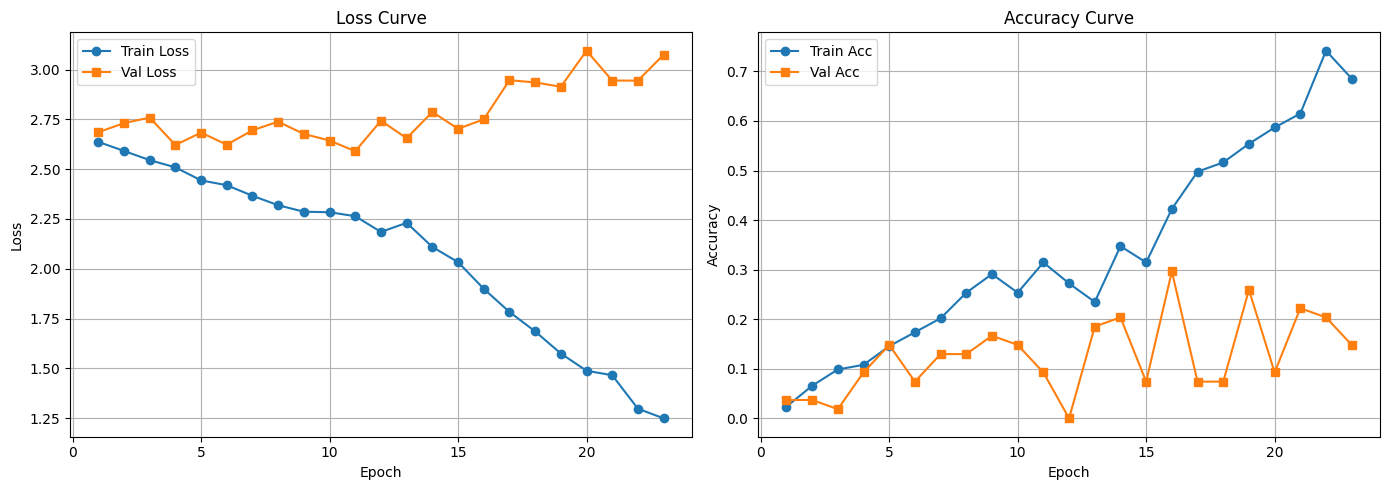

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ran, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Acc',   marker='s')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluation — Metrics, Confusion Matrix, ROC Curve

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs_raw = [], [], [] # Renamed for clarity

with torch.no_grad():
    for seqs, labels in test_loader:
        seqs = seqs.to(DEVICE)
        with autocast():
            logits = model(seqs)
        probs  = torch.softmax(logits, dim=1).cpu().numpy() # Get probabilities for all classes
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs_raw.append(probs) # Changed from .extend() to .append()

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs_raw = np.concatenate(all_probs_raw, axis=0) # Stack probabilities into (N, num_classes)

acc  = accuracy_score(all_labels, all_preds) * 100
prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100

# For multi-class AUC
if CFG['num_classes'] > 2:
    # Pass the full set of possible labels to roc_auc_score
    auc  = roc_auc_score(all_labels, all_probs_raw, multi_class='ovr', average='weighted', labels=range(CFG['num_classes'])) * 100
else: # Binary case, keep original behavior for class 1 probability
    auc  = roc_auc_score(all_labels, all_probs_raw[:, 1]) * 100
cm   = confusion_matrix(all_labels, all_preds)

print('=' * 55)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  Precision : {prec:.2f}%')
print(f'  Recall    : {rec:.2f}%')
print(f'  F1 Score  : {f1:.2f}%')
print(f'  AUC       : {auc:.2f}%')
print('=' * 55)

# Per-class accuracy
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    mask    = all_labels == cls_idx
    if np.any(mask): # Check if there are any samples for this class in the test set
        cls_acc = (all_preds[mask] == all_labels[mask]).mean() * 100
        print(f'  {cls_name} accuracy: {cls_acc:.2f}%')
    else:
        print(f'  {cls_name} accuracy: N/A (no samples in test set)')

  Accuracy  : 29.63%
  Precision : 34.14%
  Recall    : 29.63%
  F1 Score  : 29.89%
  AUC       : 59.78%
  Abuse accuracy: 0.00%
  Arrest accuracy: 0.00%
  Arson accuracy: 0.00%
  Assault accuracy: N/A (no samples in test set)
  Burglary accuracy: 33.33%
  Explosion accuracy: 0.00%
  Fighting accuracy: 0.00%
  Normal accuracy: 48.00%
  RoadAccidents accuracy: 0.00%
  Robbery accuracy: 0.00%
  Shooting accuracy: 100.00%
  Shoplifting accuracy: 33.33%
  Stealing accuracy: 0.00%
  Vandalism accuracy: 0.00%


In [ ]:
from google.colab import files
import shutil

source_path = '/content/best_model.pth'
destination_filename = 'violence_detector.pth'

try:
    shutil.copy(source_path, destination_filename)
    print(f'Model copied to {destination_filename}. Preparing for download...')
    files.download(destination_filename)
    print('Download initiated.')
except FileNotFoundError:
    print(f'Error: Model file not found at {source_path}. Please ensure the training completed successfully.')
except Exception as e:
    print(f'An error occurred during download: {e}')

Model copied to violence_detector.pth. Preparing for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated.


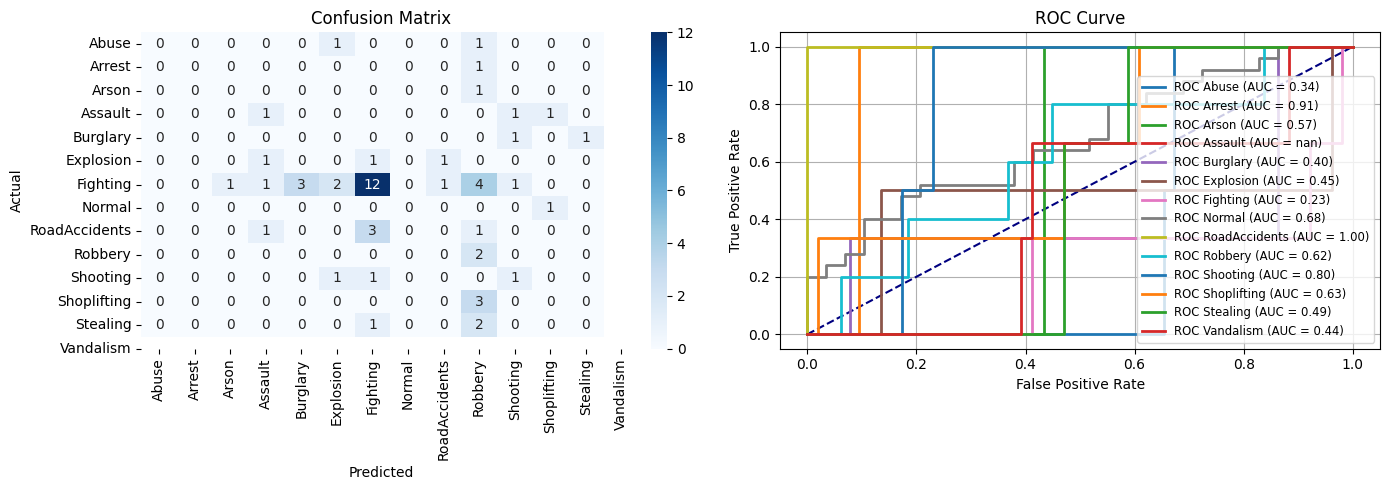

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Confusion matrix ─────────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# ── ROC curve ────────────────────────────────────────────────────────────────
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--') # Always plot baseline

if CFG['num_classes'] > 2:
    # Plot one-vs-rest ROC for each class
    for i, class_name in enumerate(CLASS_NAMES):
        class_labels = (all_labels == i).astype(int)
        class_probs  = all_probs_raw[:, i]
        fpr_i, tpr_i, _ = roc_curve(class_labels, class_probs)
        auc_i = roc_auc_score(class_labels, class_probs)
        axes[1].plot(fpr_i, tpr_i, lw=2, label=f'ROC {class_name} (AUC = {auc_i:.2f})')
    axes[1].legend(loc='lower right', fontsize='small') # Adjust legend size
else:
    # Binary ROC curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs_raw[:, 1]) # Assuming class 1 is positive
    axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC (AUC = {auc/100:.4f})') # Use the calculated AUC
    axes[1].legend(loc='lower right')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

import torch.nn.functional as F

class GradCAM:
    """Gradient-weighted Class Activation Mapping for the last conv block."""

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx=None):
        """input_tensor: (1, T, C, H, W)."""
        original_mode = self.model.training # Save model's original training state

        # Set model to train mode for both forward and backward pass for Grad-CAM
        # This addresses the cudnn RNN backward error by ensuring GRU is in train mode
        # during its forward pass as well.
        self.model.train()

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()

        self.model.zero_grad()

        # Backward pass
        output[0, class_idx].backward()

        # Restore original mode
        self.model.train(original_mode)

        # Pool gradients across channels
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def overlay_cam(frame_np, cam, alpha=0.4):
    """Overlay heatmap on original frame (numpy uint8 BGR)."""
    h, w    = frame_np.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap(
        (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    overlay = cv2.addWeighted(frame_np, 1 - alpha, heatmap, alpha, 0)
    return overlay


# Instantiate Grad-CAM on the last conv block
gradcam = GradCAM(model, model.extractor.block5[-1].conv[0])

# Visualise on a few test samples
num_samples = 4
fig, axes   = plt.subplots(2, num_samples, figsize=(16, 7))

sample_iter = iter(test_loader)
seqs, labels = next(sample_iter)

for i in range(min(num_samples, seqs.size(0))):
    single_seq = seqs[i:i+1].to(DEVICE)
    cam_sequence, pred  = gradcam.generate(single_seq)

    # Denormalise first frame for display
    frame_tensor = seqs[i, 0]  # (C, H, W)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    frame_np = ((frame_tensor * std + mean).clamp(0,1)
                .permute(1,2,0).numpy() * 255).astype(np.uint8)
    frame_bgr = cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR)

    # Select the CAM for the first frame in the sequence
    overlay = overlay_cam(frame_bgr, cam_sequence[0])
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    cls_names = CLASS_NAMES # Use the dynamically generated class names
    axes[0, i].imshow(frame_np)
    axes[0, i].set_title(f'GT: {cls_names[labels[i].item()]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'Pred: {cls_names[pred]}')
    axes[1, i].axis('off')

fig.suptitle('Grad-CAM Visualization', fontsize=14)
plt.tight_layout()
plt.savefig('/content/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

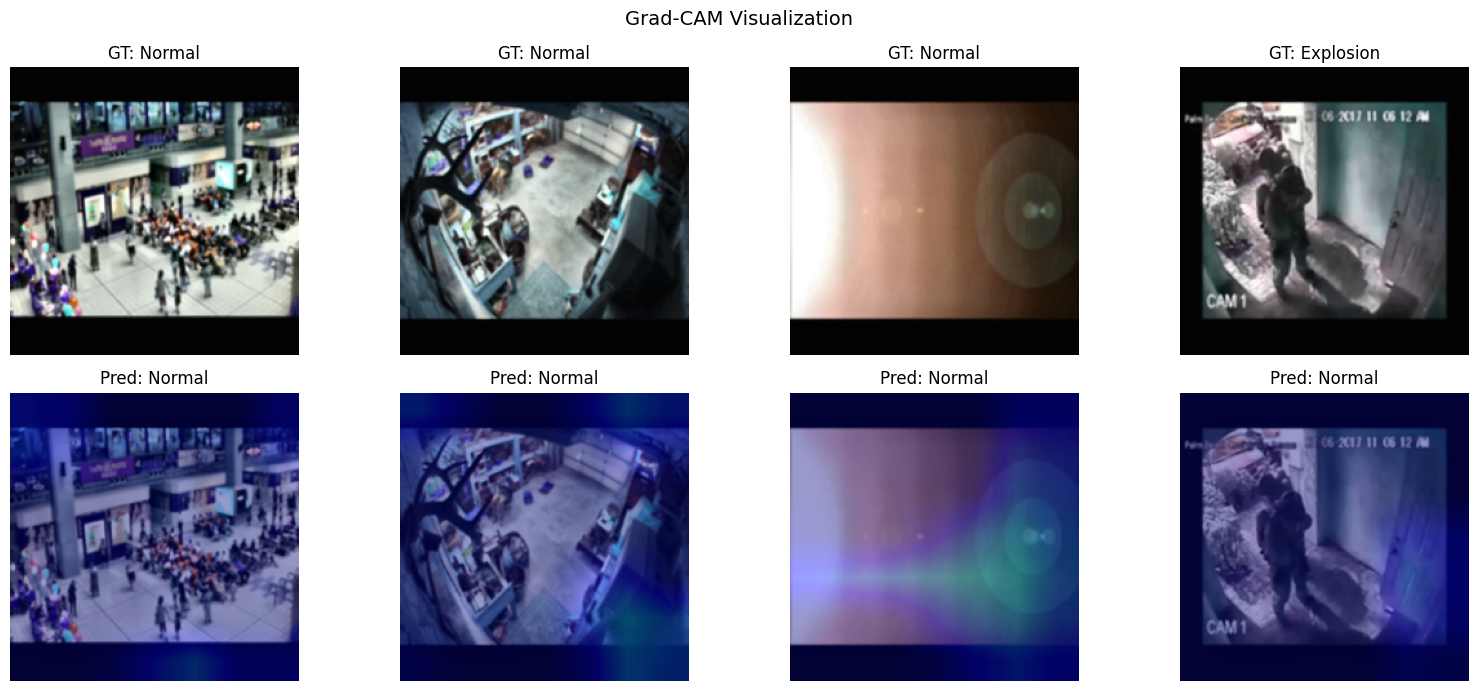

In [ ]:
import torch.nn.functional as F

class GradCAM:
    """Gradient-weighted Class Activation Mapping for the last conv block."""

    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, class_idx=None):
        """input_tensor: (1, T, C, H, W)."""
        original_mode = self.model.training # Save model's original training state

        # Set model to train mode for both forward and backward pass for Grad-CAM
        # This addresses the cudnn RNN backward error by ensuring GRU is in train mode
        # during its forward pass as well.
        self.model.train()

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()

        self.model.zero_grad()

        # Backward pass
        output[0, class_idx].backward()

        # Restore original mode
        self.model.train(original_mode)

        # Pool gradients across channels
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


def overlay_cam(frame_np, cam, alpha=0.4):
    """Overlay heatmap on original frame (numpy uint8 BGR)."""
    h, w    = frame_np.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap(
        (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    overlay = cv2.addWeighted(frame_np, 1 - alpha, heatmap, alpha, 0)
    return overlay


# Instantiate Grad-CAM on the last conv block
gradcam = GradCAM(model, model.extractor.block5[-1].conv[0])

# Visualise on a few test samples
num_samples = 4
fig, axes   = plt.subplots(2, num_samples, figsize=(16, 7))

sample_iter = iter(test_loader)
seqs, labels = next(sample_iter)

for i in range(min(num_samples, seqs.size(0))):
    single_seq = seqs[i:i+1].to(DEVICE)
    cam_sequence, pred  = gradcam.generate(single_seq)

    # Denormalise first frame for display
    frame_tensor = seqs[i, 0]  # (C, H, W)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    frame_np = ((frame_tensor * std + mean).clamp(0,1)
                .permute(1,2,0).numpy() * 255).astype(np.uint8)
    frame_bgr = cv2.cvtColor(frame_np, cv2.COLOR_RGB2BGR)

    # Select the CAM for the first frame in the sequence
    overlay = overlay_cam(frame_bgr, cam_sequence[0])
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    # Use the globally defined CLASS_NAMES for all 14 classes
    axes[0, i].imshow(frame_np)
    axes[0, i].set_title(f'GT: {CLASS_NAMES[labels[i].item()]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f'Pred: {CLASS_NAMES[pred]}')
    axes[1, i].axis('off')

fig.suptitle('Grad-CAM Visualization', fontsize=14)
plt.tight_layout()
plt.savefig('/content/gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Inference Speed Benchmark

In [ ]:
import time

model.eval()
dummy = torch.randn(1, CFG['seq_len'], 3,
                    CFG['img_size'], CFG['img_size']).to(DEVICE)

# Warm-up
for _ in range(10):
    with torch.no_grad():
        _ = model(dummy)

# Timed runs
N   = 100
t0  = time.perf_counter()
for _ in range(N):
    with torch.no_grad():
        _ = model(dummy)
if DEVICE.type == 'cuda':
    torch.cuda.synchronize()
elapsed = (time.perf_counter() - t0) / N * 1000  # ms per inference
fps     = 1000 / elapsed
#FLOP
print(f'Average inference time : {elapsed:.2f} ms/sequence')
print(f'Throughput             : {fps:.1f} sequences/sec')
if DEVICE.type == 'cuda':
    mem = torch.cuda.max_memory_allocated() / 1e6
    print(f'Peak GPU memory        : {mem:.0f} MB')

Average inference time : 14.58 ms/sequence
Throughput             : 68.6 sequences/sec
Peak GPU memory        : 2999 MB


## 15. Ablation Study

In [ ]:
# ── Ablation: measure the impact of Bi-GRU direction and Frame Attention ─────

class AblationModel(nn.Module):
    """Stripped-down model for ablation experiments."""
    def __init__(self, cfg, bidirectional=True, use_attention=True):
        super().__init__()
        feat_dim   = 512
        hidden_dim = cfg['gru_hidden']
        directions = 2 if bidirectional else 1

        self.extractor = YOLOv7TinyExtractor(cfg['img_size'], out_dim=feat_dim)
        self.gru = nn.GRU(
            input_size    = feat_dim,
            hidden_size   = hidden_dim,
            num_layers    = cfg['gru_layers'],
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = cfg['dropout'] if cfg['gru_layers'] > 1 else 0.0,
        )
        self.use_attention = use_attention
        if use_attention:
            self.attention = FrameAttention(hidden_dim * directions)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * directions, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(cfg['dropout']),
            nn.Linear(128, cfg['num_classes']),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        f = self.extractor(x).view(B, T, -1)
        g, _ = self.gru(f)
        if self.use_attention:
            ctx, _ = self.attention(g)
        else:
            ctx = g[:, -1, :]  # last hidden state
        return self.classifier(ctx)


def train_and_eval_ablation(cfg, bidirectional, use_attention, epochs=5):
    m   = AblationModel(cfg, bidirectional, use_attention).to(DEVICE)
    opt = optim.AdamW(m.parameters(), lr=cfg['lr'],
                      weight_decay=cfg['weight_decay'])
    sc  = GradScaler()

    for _ in range(epochs):
        m.train()
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            with autocast():
                loss = criterion(m(seqs), labels)
            sc.scale(loss).backward()
            sc.step(opt)
            sc.update()

    return quick_eval(m, test_loader, DEVICE)


ablation_results = {}
configs = [
    ('Uni-GRU  + No Attention',  False, False),
    ('Uni-GRU  + Attention',     False, True),
    ('Bi-GRU   + No Attention',  True,  False),
    ('Bi-GRU   + Attention',     True,  True),
]
for name, bidir, attn in configs:
    acc = train_and_eval_ablation(CFG, bidir, attn, epochs=5)
    ablation_results[name] = acc
    print(f'{name:30s}  Acc: {acc*100:.2f}%')

# Plot ablation
plt.figure(figsize=(9, 5))
bars = plt.bar(ablation_results.keys(),
               [v * 100 for v in ablation_results.values()],
               color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.ylabel('Accuracy (%)')
plt.title('Ablation Study')
plt.xticks(rotation=15, ha='right')
plt.ylim(40, 100)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('/content/ablation.png', dpi=150, bbox_inches='tight')
plt.show()

Uni-GRU  + No Attention         Acc: 12.96%


## 16. Comparison Table (Paper Benchmarks)

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    ['3D CNN',                  52.21, 52.02, 50.02, 50.98, 52.83],
    ['VGG16',                   72.66, 72.00, 71.50, 71.75, 73.00],
    ['DEARESt',                 55.17, 30.44, 55.17, 39.23, 38.52],
    ['Attention Residual LSTM', 78.43, 78.00, 78.50, 78.25, 78.60],
    ['YOLOv7-Tiny + Bi-GRU (Ours)', acc,   prec,  rec,   f1,    auc],
], columns=['Method', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC'])

print(comparison.to_string(index=False))

## 17. Save Model and Export

In [ ]:
# Save full model state dict
torch.save({
    'model_state_dict' : model.state_dict(),
    'optimizer_state'  : optimizer.state_dict(),
    'cfg'              : CFG,
    'best_val_acc'     : best_val_acc,
    'history'          : history,
}, '/content/violence_detector_final.pth')

print('Model saved to /content/violence_detector_final.pth')

# Optional: copy to Google Drive
# import shutil
# shutil.copy('/content/violence_detector_final.pth',
#             '/content/drive/MyDrive/violence_detector_final.pth')

print('Done.')